In [13]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
OUTPUT_DIR = Path("_output")
OUTPUT_DIR.mkdir(exist_ok=True)

<Axes: >

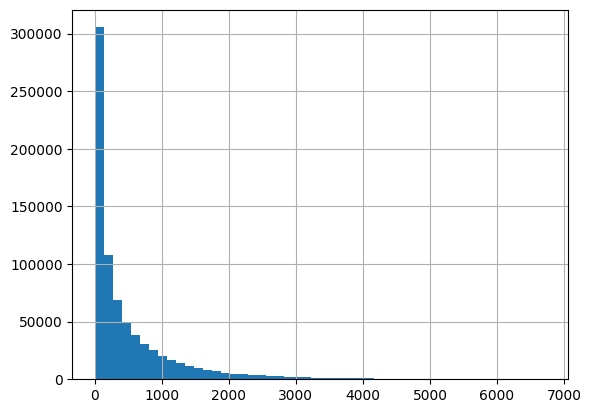

In [1]:
from pathlib import Path
import pandas as pd

ROOT_DIR = Path().resolve().parents[0]  
DATA_DIR = ROOT_DIR / "_data"
df = pd.read_parquet(DATA_DIR / "optionmetrics_spx_monthly.parquet")
df["mid_price"].hist(bins=50)

In [2]:
# 1. Daily S&P 500 index returns (CRSP)
sp500_daily = pd.read_parquet(DATA_DIR / "crsp_sp500_daily.parquet")
# 2. Treasury returns
treasury_returns = pd.read_parquet(DATA_DIR / "crsp_treasury_returns.parquet")
# 3. Treasury yields from FRED 
fred_rates = pd.read_parquet(DATA_DIR / "fred_treasury_rates.parquet")
# 4. SPX options (month-end)
options = pd.read_parquet(DATA_DIR / "optionmetrics_spx_monthly.parquet")


In [3]:
for name, df in {
    "SP500 daily": sp500_daily,
    "Treasury returns": treasury_returns,
    "FRED rates": fred_rates,
    "Options (SPX, month-end)": options,
}.items():
    print(f"{name:25s} | shape = {df.shape}")

SP500 daily               | shape = (7300, 4)
Treasury returns          | shape = (348, 3)
FRED rates                | shape = (7828, 4)
Options (SPX, month-end)  | shape = (760830, 15)


# S&P 500 

In [4]:
import numpy as np
sp500_daily["date"] = pd.to_datetime(sp500_daily["date"])
sp500_daily = sp500_daily.set_index("date").sort_index()
mkt_log = np.log1p(sp500_daily["vwretd"])

In [5]:
def summary_stats(log_ret, periods_per_year):
    ann_mean = log_ret.mean() * periods_per_year * 100
    ann_std = log_ret.std() * np.sqrt(periods_per_year) * 100
    sharpe = ann_mean / ann_std
    ar1 = log_ret.autocorr(lag=1)
    n = log_ret.dropna().shape[0]
    
    return pd.Series({
        "Mean (%)": ann_mean,
        "Std. dev. (%)": ann_std,
        "Sharpe ratio": sharpe,
        "AR(1)": ar1,
        "N": n
    })

In [6]:
table1_raw = pd.DataFrame({
    "Market": summary_stats(mkt_log, periods_per_year=252),
})

In [7]:
table1_raw

,Market
Mean (%),9.155026
Std. dev. (%),18.982398
Sharpe ratio,0.482290
AR(1),-0.059368
N,7300.000000


<Axes: title={'center': 'Cumulative Market Returns (S&P 500)'}, xlabel='date'>

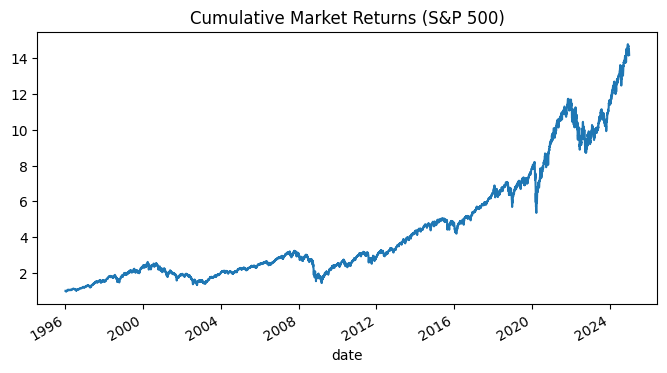

In [8]:
cum_mkt = np.exp(mkt_log.cumsum())
cum_mkt.plot(
    title="Cumulative Market Returns (S&P 500)",
    figsize=(8, 4)
)

Rolling volatility

<Axes: title={'center': 'Rolling 1-Year Annualized Volatility (Market)'}, xlabel='date'>

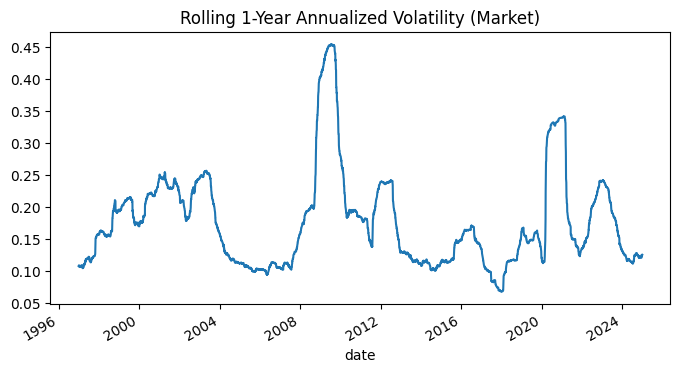

In [9]:
rolling_vol_mkt = (
    mkt_log
    .rolling(252)
    .std()
    * np.sqrt(252)
)

rolling_vol_mkt.plot(
    title="Rolling 1-Year Annualized Volatility (Market)",
    figsize=(8, 4)
)


In [10]:
sp500_daily["vwretd"].describe()

count    7300.000000
mean        0.000435
std         0.011932
min        -0.118167
25%        -0.004575
50%         0.000780
75%         0.006113
max         0.114918
Name: vwretd, dtype: float64

# Treasury Rates from FRED

In [18]:
print(fred_rates.head())
print("\nColumns:", fred_rates.columns.tolist())
print("Index name:", fred_rates.index.name)

             rf_1m  treasury_2y  treasury_10y
date                                         
1996-01-01     NaN          NaN           NaN
1996-01-02  0.0002       0.0518        0.0560
1996-01-03  0.0002       0.0517        0.0558
1996-01-04  0.0002       0.0517        0.0565
1996-01-05  0.0002       0.0520        0.0569

Columns: ['rf_1m', 'treasury_2y', 'treasury_10y']
Index name: date


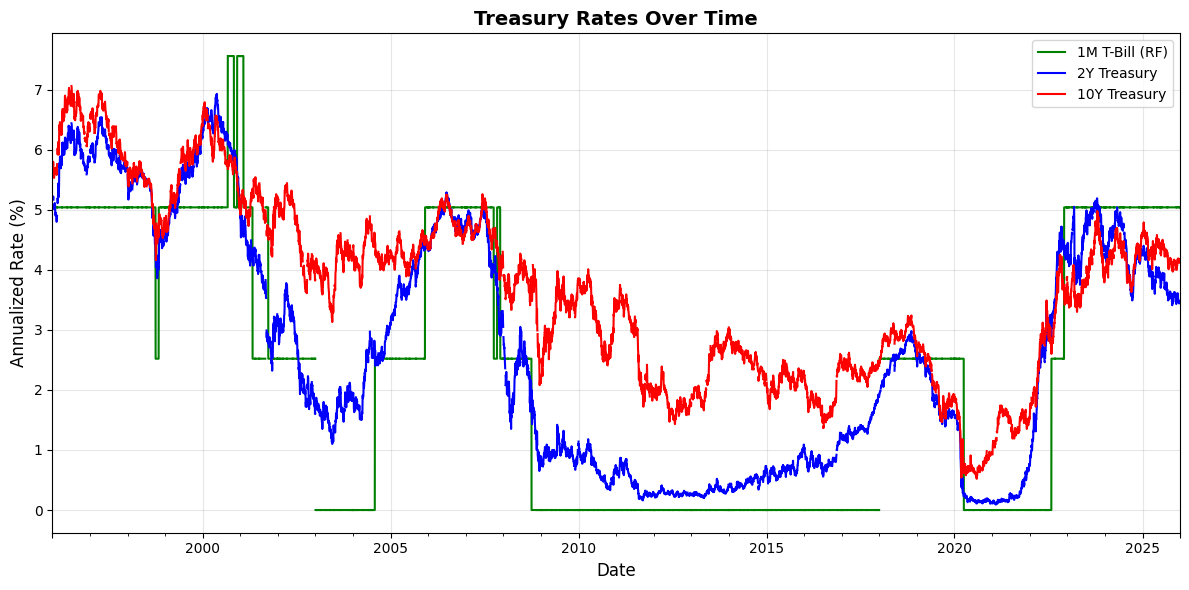

In [23]:
fred_rates_year = fred_rates.copy()
fred_rates_year['rf_1m'] = fred_rates['rf_1m'] * 252  
fred_rates_year.index = pd.to_datetime(fred_rates_year.index)
fred_rates_year = fred_rates_year.sort_index()
fig, ax = plt.subplots(figsize=(12, 6))

# Plot all three rates
(fred_rates_year["rf_1m"] * 100).plot(ax=ax, label="1M T-Bill (RF)", linewidth=1.5, color='green')
(fred_rates_year["treasury_2y"] * 100).plot(ax=ax, label="2Y Treasury", linewidth=1.5, color='blue')
(fred_rates_year["treasury_10y"] * 100).plot(ax=ax, label="10Y Treasury", linewidth=1.5, color='red')

ax.set_title("Treasury Rates Over Time", fontsize=14, fontweight='bold')
ax.set_ylabel("Annualized Rate (%)", fontsize=12)
ax.set_xlabel("Date", fontsize=12)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart2_treasury_rates.png", dpi=150)
plt.show()

# Treasury Returns from CRSP

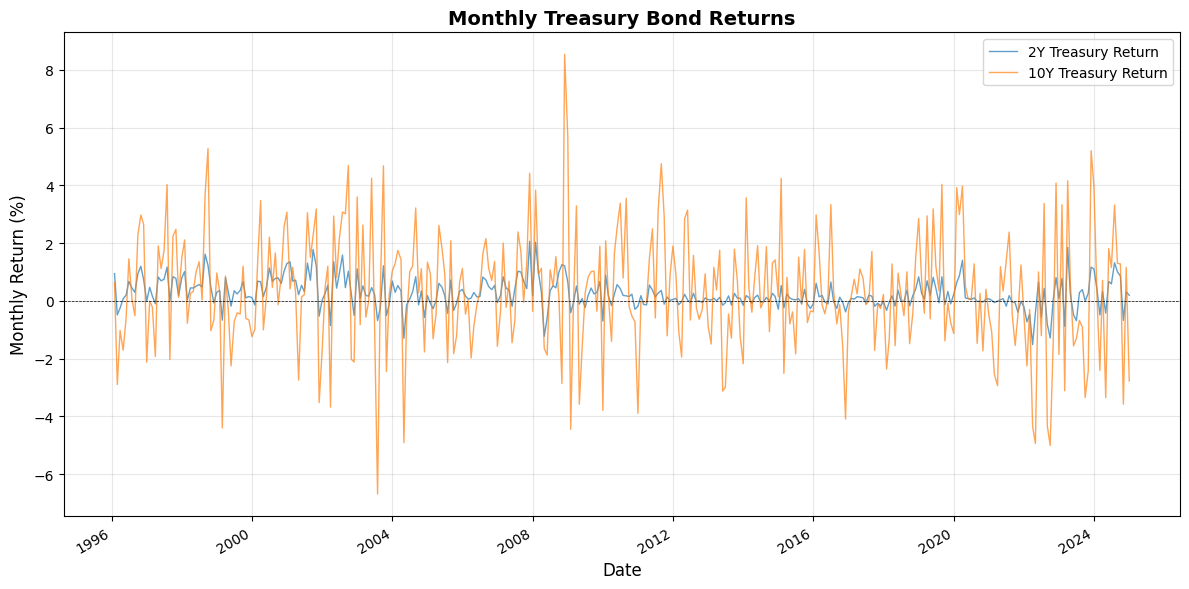

In [28]:
treasury_returns.index = pd.to_datetime(treasury_returns.index)
treasury_returns = treasury_returns.sort_index()

fig, ax = plt.subplots(figsize=(12, 6))

# Plot monthly returns
(treasury_returns["treasury_2y_ret"] * 100).plot(
    ax=ax, label="2Y Treasury Return", linewidth=1, alpha=0.7
)
(treasury_returns["treasury_10y_ret"] * 100).plot(
    ax=ax, label="10Y Treasury Return", linewidth=1, alpha=0.7
)

ax.set_title("Monthly Treasury Bond Returns", fontsize=14, fontweight='bold')
ax.set_ylabel("Monthly Return (%)", fontsize=12)
ax.set_xlabel("Date", fontsize=12)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart3_treasury_returns.png", dpi=150)
plt.show()

# Options Data

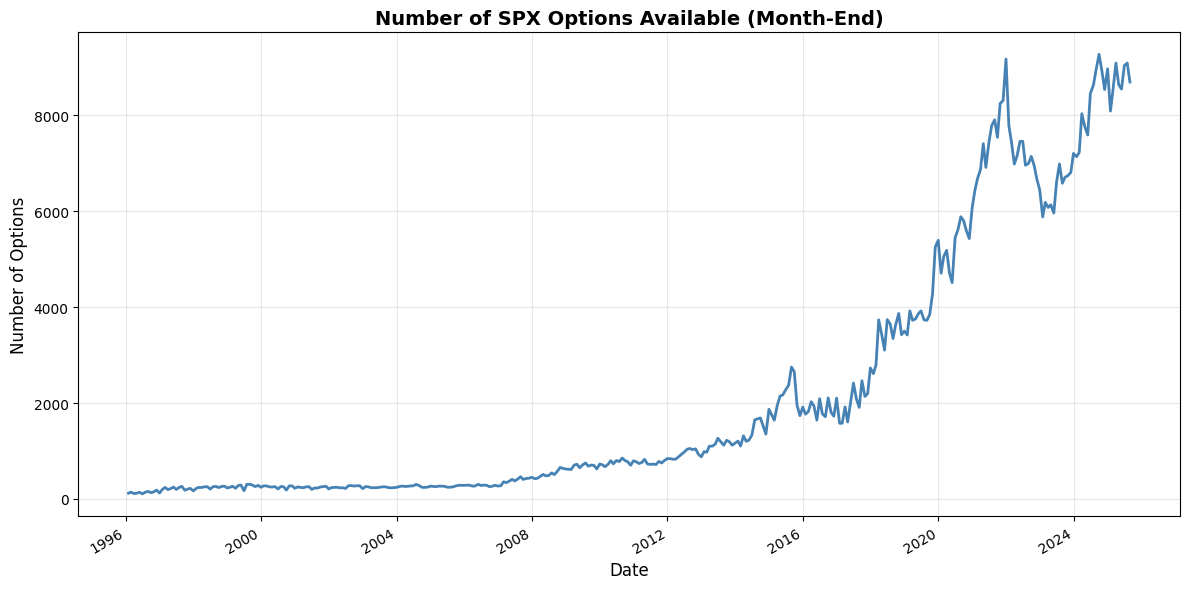

In [29]:
# Number of Options Per Month
if "date" not in options.columns:
    options = options.reset_index()
    
options["date"] = pd.to_datetime(options["date"])

# Count options per month
monthly_counts = options.groupby("date").size()

fig, ax = plt.subplots(figsize=(12, 6))
monthly_counts.plot(ax=ax, linewidth=2, color='steelblue')
ax.set_title("Number of SPX Options Available (Month-End)", 
             fontsize=14, fontweight='bold')
ax.set_ylabel("Number of Options", fontsize=12)
ax.set_xlabel("Date", fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart4_options_count.png", dpi=150)
plt.show()

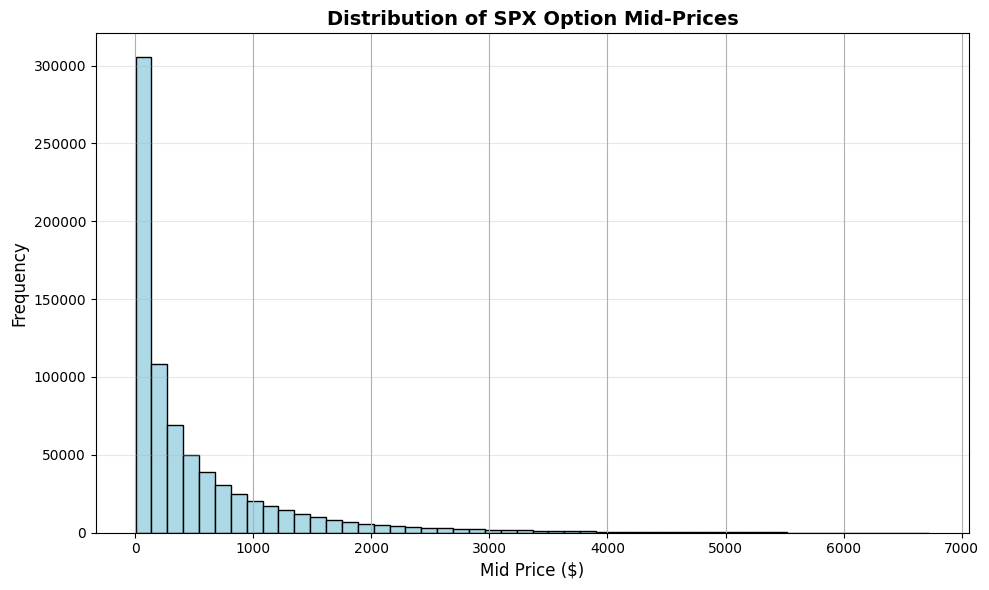

In [30]:
# Option Price Distribution
fig, ax = plt.subplots(figsize=(10, 6))

options["mid_price"].hist(bins=50, ax=ax, edgecolor='black', color='lightblue')
ax.set_title("Distribution of SPX Option Mid-Prices", 
             fontsize=14, fontweight='bold')
ax.set_xlabel("Mid Price ($)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart4_options_prices.png", dpi=150)
plt.show()

In [31]:
# Summary statistics
print("Options Data Summary:")
print(f"Total options: {len(options):,}")
print(f"Date range: {options['date'].min()} to {options['date'].max()}")
print(f"Unique months: {options['date'].nunique()}")
print(f"\nPrice statistics:")
print(options["mid_price"].describe())

Options Data Summary:
Total options: 760,830
Date range: 1996-01-31 00:00:00 to 2025-08-29 00:00:00
Unique months: 356

Price statistics:
count    760830.000000
mean        517.676181
std         736.202251
min           3.000000
25%          56.650000
50%         222.850000
75%         673.187500
max        6726.800000
Name: mid_price, dtype: float64
